# 📡 TelecomX LATAM — Análisis de Evasión de Clientes (Churn)

> **Objetivo:** Identificar los factores que llevan a los clientes de TelecomX a cancelar su servicio, cuantificar el impacto financiero y proponer acciones concretas de retención.

---
| Sección | Descripción |
|---|---|
| 📌 Extracción | Carga de datos desde la API |
| 🔧 Transformación | Limpieza, normalización y enriquecimiento |
| 📊 Análisis Exploratorio | Visualización de patrones de evasión |
| 🔬 Análisis Avanzado | Insights profundos y prueba de hipótesis |
| 💰 Impacto Financiero | Cuantificación del problema |
| 📝 Conclusiones | Recomendaciones estratégicas |


## 📌 1. Extracción

### 1.1 Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120


### 1.2 Carga de datos desde la API

In [2]:
URL = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

df_raw = pd.read_json(URL)
print(f"✅ Dataset cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
df_raw.head(3)


✅ Dataset cargado: 7,267 filas × 6 columnas


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


### 1.3 Normalización de columnas anidadas (JSON flatten)

In [3]:
df_dict = df_raw.to_dict(orient="records")
df = pd.json_normalize(df_dict, sep='_')
print(f"✅ Columnas tras normalización: {df.shape[1]}")
df.head(3)


✅ Columnas tras normalización: 21


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


## 🔧 2. Transformación

### 📖 Diccionario de datos

| Variable | Descripción |
|---|---|
| `customerID` | Identificador único del cliente |
| `Churn` | ¿El cliente canceló el servicio? (target) |
| `gender` | Género del cliente |
| `SeniorCitizen` | ¿Tiene 65 años o más? (0/1) |
| `Partner` | ¿Tiene pareja? |
| `Dependents` | ¿Tiene dependientes? |
| `tenure` | Meses de permanencia |
| `PhoneService` | Servicio telefónico |
| `MultipleLines` | Líneas múltiples |
| `InternetService` | Tipo de servicio de internet |
| `OnlineSecurity / Backup / DeviceProtection / TechSupport` | Servicios adicionales |
| `StreamingTV / StreamingMovies` | Streaming |
| `Contract` | Tipo de contrato |
| `PaperlessBilling` | Facturación electrónica |
| `PaymentMethod` | Método de pago |
| `Charges.Monthly / Total` | Cargos mensuales y acumulados |


### 2.1 Auditoría de calidad de datos

In [4]:
# Limpieza de espacios en strings
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

print("=" * 55)
print("  AUDITORÍA DE CALIDAD DEL DATASET")
print("=" * 55)
print(f"\nDimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\n{'Columna':<35} {'Nulos':>6} {'Vacíos':>7}")
print("-" * 55)
for col in df.columns:
    nulos = df[col].isna().sum()
    vacios = (df[col] == '').sum() if df[col].dtype == 'object' else 0
    if nulos > 0 or vacios > 0:
        print(f"  {col:<33} {nulos:>6} {vacios:>7}")

print(f"\n  Clientes únicos: {df['customerID'].nunique():,}")
print(f"  Filas duplicadas: {df.duplicated().sum()}")
print("=" * 55)


  AUDITORÍA DE CALIDAD DEL DATASET

Dimensiones: 7,267 filas × 21 columnas

Columna                              Nulos  Vacíos
-------------------------------------------------------

  Clientes únicos: 7,267
  Filas duplicadas: 0


**Hallazgos:**
- 224 valores vacíos en `Churn` → se eliminarán
- 11 valores vacíos en `account_Charges_Total` → tipo de dato incorrecto, se convertirá a numérico
- Sin clientes duplicados


### 2.2 Corrección de tipos y valores faltantes

In [5]:
# Eliminar filas sin valor en Churn
df = df[df['Churn'] != ''].copy()

# Convertir Charges.Total a numérico (los vacíos → NaN → 0)
df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce').fillna(0)

# Convertir columnas binarias Yes/No → 1/0
cols_binarias = ['customer_Partner', 'customer_Dependents', 'phone_PhoneService', 'account_PaperlessBilling']
df[cols_binarias] = df[cols_binarias].apply(lambda col: col.map({'Yes': 1, 'No': 0}).astype(int))

# Convertir Churn a binario
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}).astype(int)

print(f"✅ Dataset limpio: {df.shape[0]:,} filas")


✅ Dataset limpio: 7,043 filas


### 2.3 Ingeniería de características

In [6]:
# Nueva columna: costo diario estimado
df['account_Charges_Daily'] = (df['account_Charges_Monthly'] / 30).round(2)

print("✅ Nueva columna 'account_Charges_Daily' creada")
df[['customerID', 'account_Charges_Monthly', 'account_Charges_Daily']].head(3)


✅ Nueva columna 'account_Charges_Daily' creada


,customerID,account_Charges_Monthly,account_Charges_Daily
0,0002-ORFBO,65.6,2.19
1,0003-MKNFE,59.9,2.00
2,0004-TLHLJ,73.9,2.46


### 2.4 Renombrado y traducción de columnas y valores

In [7]:
# Renombrar columnas
df = df.rename(columns={
    'Churn': 'Evasion',
    'customer_gender': 'Genero',
    'customer_SeniorCitizen': 'Adulto_Mayor',
    'customer_Partner': 'Pareja',
    'customer_Dependents': 'Dependientes',
    'customer_tenure': 'Meses_Permanencia',
    'phone_PhoneService': 'Servicio_Telefonico',
    'phone_MultipleLines': 'Multiples_Lineas',
    'internet_InternetService': 'Servicio_Internet',
    'internet_OnlineSecurity': 'Seguridad_Linea',
    'internet_OnlineBackup': 'Backup_Linea',
    'internet_DeviceProtection': 'Proteccion_Dispositivo',
    'internet_TechSupport': 'Soporte_Tecnico',
    'internet_StreamingTV': 'Streaming_TV',
    'internet_StreamingMovies': 'Streaming_Peliculas',
    'account_Contract': 'Contrato',
    'account_PaperlessBilling': 'Facturacion_Digital',
    'account_PaymentMethod': 'Metodo_Pago',
    'account_Charges_Monthly': 'Cargo_Mensual',
    'account_Charges_Total': 'Cargo_Total',
    'account_Charges_Daily': 'Cargo_Diario'
})

# Traducir valores categóricos
df['Genero'] = df['Genero'].map({'Male': 'Hombre', 'Female': 'Mujer'})
df['Adulto_Mayor'] = df['Adulto_Mayor'].map({1: 'Sí', 0: 'No'})

df['Contrato'] = df['Contrato'].map({
    'Month-to-month': 'Mes a mes',
    'One year': 'Un año',
    'Two year': 'Dos años'
})

df['Metodo_Pago'] = df['Metodo_Pago'].map({
    'Electronic check': 'Cheque electrónico',
    'Mailed check': 'Cheque por correo',
    'Bank transfer (automatic)': 'Transferencia bancaria',
    'Credit card (automatic)': 'Tarjeta de crédito'
})

df['Servicio_Internet'] = df['Servicio_Internet'].map({
    'DSL': 'DSL', 'Fiber optic': 'Fibra óptica', 'No': 'No'
})

cols_internet = ['Seguridad_Linea', 'Backup_Linea', 'Proteccion_Dispositivo',
                 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas']
df[cols_internet] = df[cols_internet].replace({
    'Yes': 'Sí', 'No': 'No', 'No internet service': 'Sin internet'
})
df['Multiples_Lineas'] = df['Multiples_Lineas'].replace({
    'Yes': 'Sí', 'No': 'No', 'No phone service': 'Sin teléfono'
})
df['Facturacion_Digital'] = df['Facturacion_Digital'].map({1: 'Sí', 0: 'No'})
df['Servicio_Telefonico'] = df['Servicio_Telefonico'].map({1: 'Sí', 0: 'No'})
df['Pareja'] = df['Pareja'].map({1: 'Sí', 0: 'No'})
df['Dependientes'] = df['Dependientes'].map({1: 'Sí', 0: 'No'})

print("✅ Dataset final listo")
df.info()


✅ Dataset final listo
<class 'pandas.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customerID              7043 non-null   str    
 1   Evasion                 7043 non-null   int64  
 2   Genero                  7043 non-null   str    
 3   Adulto_Mayor            7043 non-null   str    
 4   Pareja                  7043 non-null   str    
 5   Dependientes            7043 non-null   str    
 6   Meses_Permanencia       7043 non-null   int64  
 7   Servicio_Telefonico     7043 non-null   str    
 8   Multiples_Lineas        7043 non-null   str    
 9   Servicio_Internet       7043 non-null   str    
 10  Seguridad_Linea         7043 non-null   str    
 11  Backup_Linea            7043 non-null   str    
 12  Proteccion_Dispositivo  7043 non-null   str    
 13  Soporte_Tecnico         7043 non-null   str    
 14  Streaming_TV            7043 non-n

### 2.5 Muestra del dataset final

In [8]:
df.sample(5, random_state=42)

,customerID,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Permanencia,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Facturacion_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cargo_Diario
190,0301-KOBTQ,0,Hombre,No,No,No,32,Sí,No,No,...,Sin internet,Sin internet,Sin internet,Sin internet,Dos años,Sí,Transferencia bancaria,20.05,614.45,0.67
2787,3865-YIOTT,0,Hombre,No,Sí,Sí,72,Sí,Sí,Fibra óptica,...,Sí,No,Sí,Sí,Un año,Sí,Transferencia bancaria,106.10,7848.50,3.54
3935,5377-NDTOU,0,Mujer,No,Sí,Sí,71,Sí,Sí,DSL,...,Sí,Sí,Sí,Sí,Dos años,No,Cheque por correo,91.05,6293.75,3.03
1854,2637-FKFSY,0,Mujer,No,Sí,No,3,Sí,No,DSL,...,No,No,No,No,Mes a mes,Sí,Cheque por correo,46.10,130.15,1.54
136,0224-NIJLP,0,Hombre,No,Sí,Sí,8,Sí,No,No,...,Sin internet,Sin internet,Sin internet,Sin internet,Dos años,No,Cheque por correo,20.15,165.50,0.67


### 2.6 Estadísticas descriptivas

In [9]:
df.describe()

,Evasion,Meses_Permanencia,Cargo_Mensual,Cargo_Total,Cargo_Diario
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,32.371149,64.761692,2279.734304,2.158675
std,0.441561,24.559481,30.090047,2266.794470,1.003088
min,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,9.000000,35.500000,398.550000,1.180000
50%,0.000000,29.000000,70.350000,1394.550000,2.340000
75%,1.000000,55.000000,89.850000,3786.600000,2.990000
max,1.000000,72.000000,118.750000,8684.800000,3.960000


## 📊 3. Análisis Exploratorio de Datos (EDA)

> En esta sección exploramos visualmente la distribución de la evasión y su relación con las variables principales del dataset.


### 3.1 Tasa global de evasión

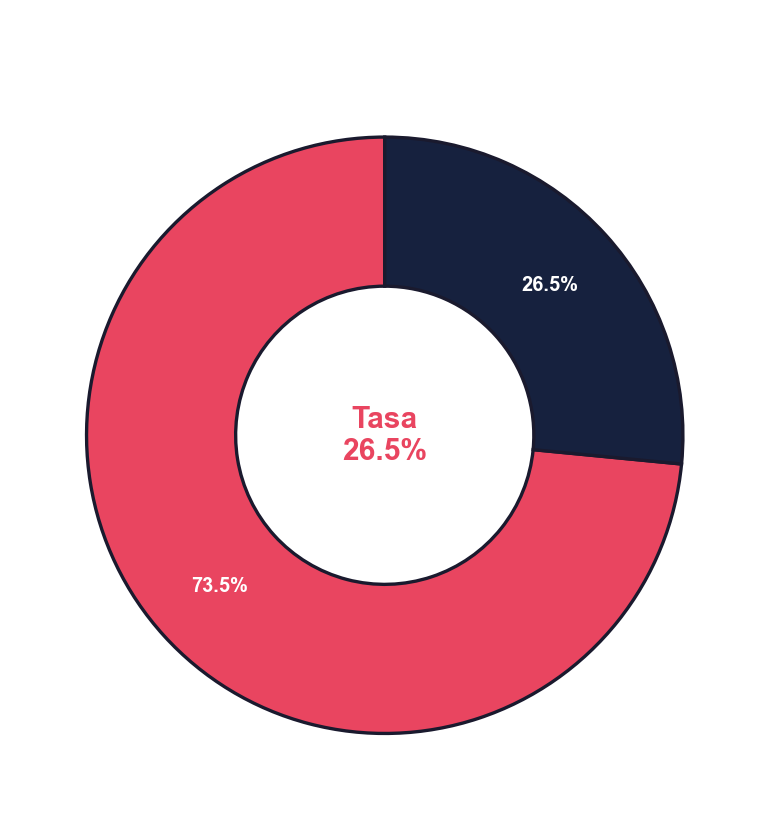

  Clientes que cancelaron:   1,869  (26.5%)
  Clientes que permanecen:   5,174  (73.5%)


In [10]:
cancelaciones = df['Evasion'].value_counts().rename({1: 'Cancelaron', 0: 'Permanecen'})
tasa = df['Evasion'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 7), facecolor='#1a1a2e')

colors = ['#e94560', '#16213e']
wedges, texts, autotexts = ax.pie(
    cancelaciones,
    labels=cancelaciones.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='#1a1a2e', linewidth=2),
    pctdistance=0.75,
    colors=colors
)

for t in texts:
    t.set_color('white'); t.set_fontsize(13); t.set_alpha(0.85)
for t in autotexts:
    t.set_color('white'); t.set_fontsize(12); t.set_fontweight('bold')

ax.text(0, 0, f'Tasa\n{tasa:.1f}%', ha='center', va='center',
        color='#e94560', fontsize=18, fontweight='bold')

ax.set_title('Distribución Global de Evasión de Clientes', color='white',
             fontsize=15, pad=20, alpha=0.9)

fig.patch.set_alpha(0)
plt.tight_layout()
plt.show()

print(f"  Clientes que cancelaron:   {cancelaciones['Cancelaron']:,}  ({tasa:.1f}%)")
print(f"  Clientes que permanecen:   {cancelaciones['Permanecen']:,}  ({100-tasa:.1f}%)")


**⚠️ La tasa de evasión del ~26% es significativamente alta** y representa un riesgo financiero crítico para TelecomX. La industria telecom suele considerar tasas superiores al 15% como un problema urgente.

### 3.2 Perfil demográfico y tasa de evasión

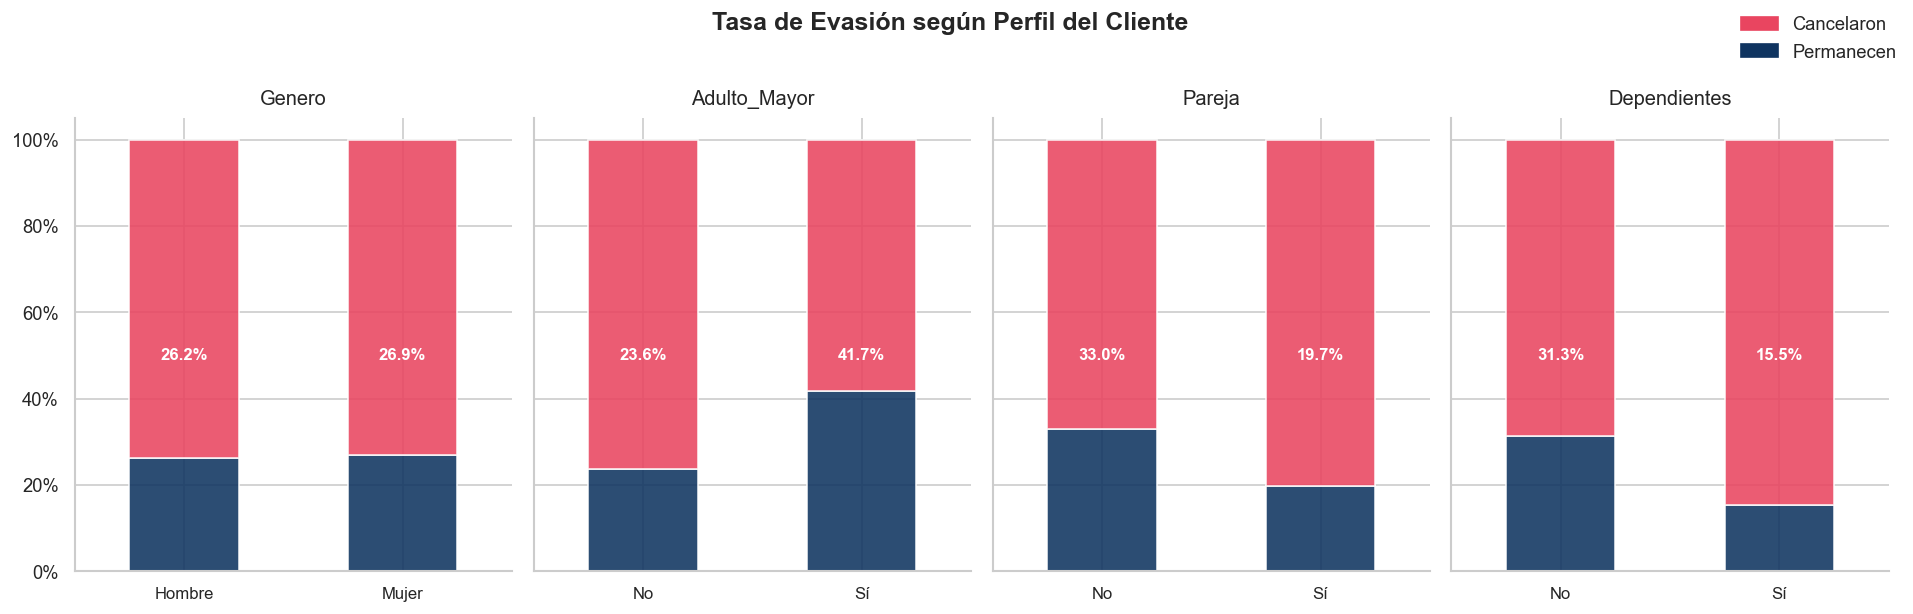

In [11]:
caracteristicas = ['Genero', 'Adulto_Mayor', 'Pareja', 'Dependientes']

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
fig.suptitle('Tasa de Evasión según Perfil del Cliente', fontsize=15, y=1.02, fontweight='bold')

palette = {'Cancelaron': '#e94560', 'Permanecen': '#0f3460'}

for i, col in enumerate(caracteristicas):
    df_plot = df.copy()
    df_plot['Estado'] = df_plot['Evasion'].map({1: 'Cancelaron', 0: 'Permanecen'})
    tabla = pd.crosstab(df_plot[col], df_plot['Estado'], normalize='index') * 100

    tabla.plot(kind='bar', stacked=True, ax=axes[i],
               color=[palette['Permanecen'], palette['Cancelaron']], alpha=0.88, legend=False)

    # Añadir etiquetas de % de cancelación en las barras
    for j, (idx, row) in enumerate(tabla.iterrows()):
        val = row.get('Cancelaron', 0)
        axes[i].text(j, 50, f'{val:.1f}%', ha='center', va='center',
                     color='white', fontsize=10, fontweight='bold')

    axes[i].set_title(col, fontsize=12, pad=8)
    axes[i].set_xlabel('')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0, fontsize=10)
    axes[i].spines[['top', 'right']].set_visible(False)

handles = [Patch(color=palette['Cancelaron'], label='Cancelaron'),
           Patch(color=palette['Permanecen'], label='Permanecen')]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=11)
plt.tight_layout()
plt.show()


### 3.3 Tipo de contrato

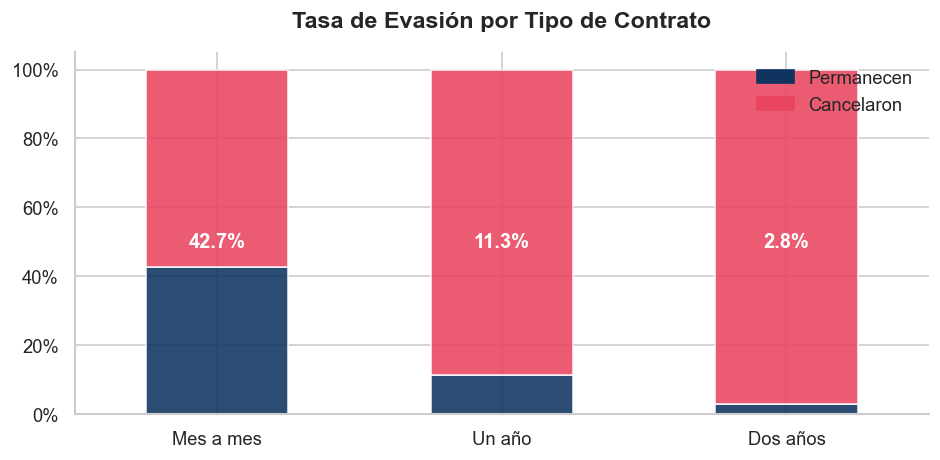

In [12]:
df_plot = df.copy()
df_plot['Estado'] = df_plot['Evasion'].map({1: 'Cancelaron', 0: 'Permanecen'})

tabla = pd.crosstab(df_plot['Contrato'], df_plot['Estado'], normalize='index') * 100
tabla = tabla.sort_values('Cancelaron', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
tabla.plot(kind='bar', stacked=True, ax=ax,
           color=['#0f3460', '#e94560'], alpha=0.88, legend=False)

for j, (idx, row) in enumerate(tabla.iterrows()):
    ax.text(j, 50, f'{row.get("Cancelaron", 0):.1f}%', ha='center', va='center',
            color='white', fontsize=12, fontweight='bold')

ax.set_title('Tasa de Evasión por Tipo de Contrato', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.spines[['top', 'right']].set_visible(False)
handles = [Patch(color='#0f3460', label='Permanecen'), Patch(color='#e94560', label='Cancelaron')]
ax.legend(handles=handles, frameon=False)
plt.tight_layout()
plt.show()


**💡 Insight clave:** Los clientes con contrato **mes a mes** cancelan a una tasa ~4 veces mayor que los de contratos anuales o bianuales. Son el segmento más vulnerable.

### 3.4 Método de pago

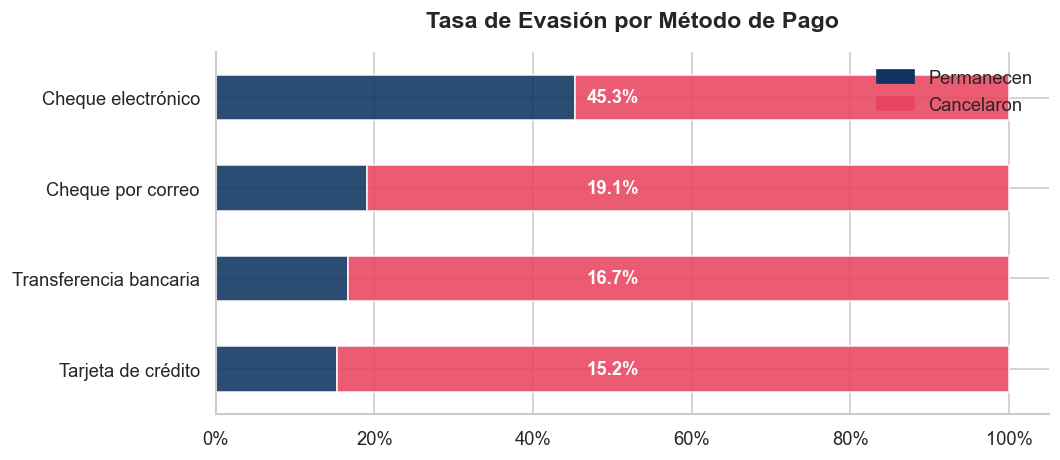

In [13]:
tabla_pago = pd.crosstab(df_plot['Metodo_Pago'], df_plot['Estado'], normalize='index') * 100
tabla_pago = tabla_pago.sort_values('Cancelaron', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
tabla_pago.plot(kind='barh', stacked=True, ax=ax,
                color=['#0f3460', '#e94560'], alpha=0.88, legend=False)

for j, (idx, row) in enumerate(tabla_pago.iterrows()):
    ax.text(50, j, f'{row.get("Cancelaron", 0):.1f}%', ha='center', va='center',
            color='white', fontsize=11, fontweight='bold')

ax.set_title('Tasa de Evasión por Método de Pago', fontsize=14, pad=15, fontweight='bold')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.spines[['top', 'right']].set_visible(False)
handles = [Patch(color='#0f3460', label='Permanecen'), Patch(color='#e94560', label='Cancelaron')]
ax.legend(handles=handles, frameon=False)
plt.tight_layout()
plt.show()


### 3.5 Tipo de servicio de internet

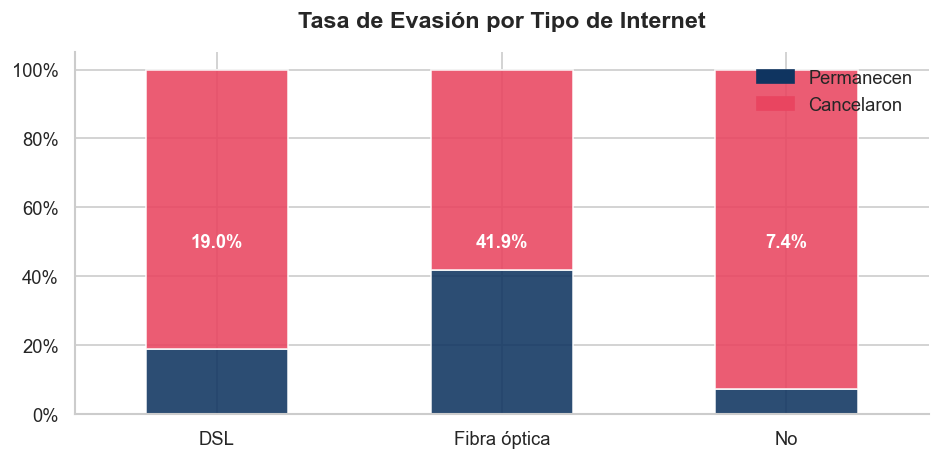

In [14]:
tabla_internet = pd.crosstab(df_plot['Servicio_Internet'], df_plot['Estado'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 4))
tabla_internet.plot(kind='bar', stacked=True, ax=ax,
                    color=['#0f3460', '#e94560'], alpha=0.88, legend=False)

for j, (idx, row) in enumerate(tabla_internet.iterrows()):
    ax.text(j, 50, f'{row.get("Cancelaron", 0):.1f}%', ha='center', va='center',
            color='white', fontsize=11, fontweight='bold')

ax.set_title('Tasa de Evasión por Tipo de Internet', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.spines[['top', 'right']].set_visible(False)
handles = [Patch(color='#0f3460', label='Permanecen'), Patch(color='#e94560', label='Cancelaron')]
ax.legend(handles=handles, frameon=False)
plt.tight_layout()
plt.show()


### 3.6 Distribuciones numéricas: Permanencia y Cargo Total

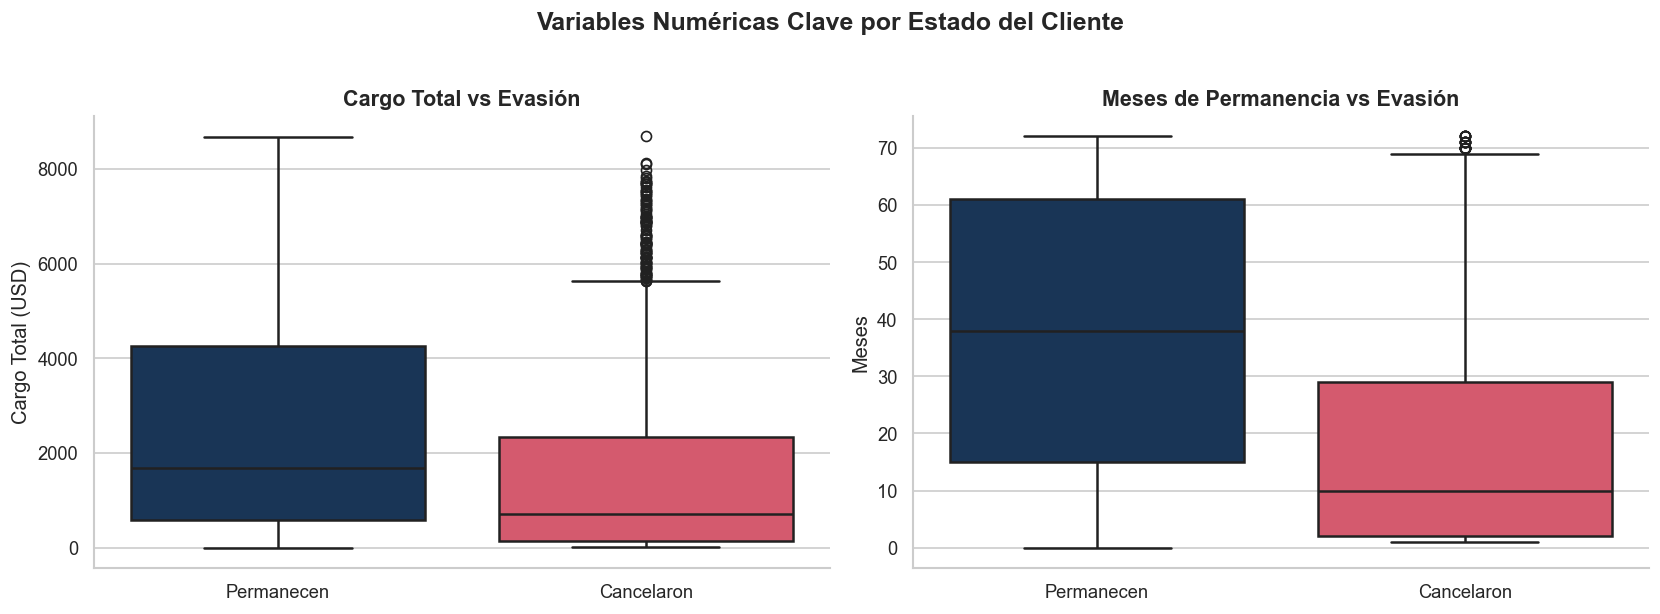

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette_estado = {'Cancelaron': '#e94560', 'Permanecen': '#0f3460'}

sns.boxplot(data=df_plot, x='Estado', y='Cargo_Total', palette=palette_estado,
            ax=axes[0], linewidth=1.5)
axes[0].set_title('Cargo Total vs Evasión', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Cargo Total (USD)')
axes[0].spines[['top', 'right']].set_visible(False)

sns.boxplot(data=df_plot, x='Estado', y='Meses_Permanencia', palette=palette_estado,
            ax=axes[1], linewidth=1.5)
axes[1].set_title('Meses de Permanencia vs Evasión', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Meses')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Variables Numéricas Clave por Estado del Cliente', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 🔬 4. Análisis Avanzado e Insights

> Vamos más allá de lo evidente: buscamos los **patrones ocultos** que explican la evasión y que pueden convertirse en palancas de acción.


### 4.1 Mapa de correlaciones

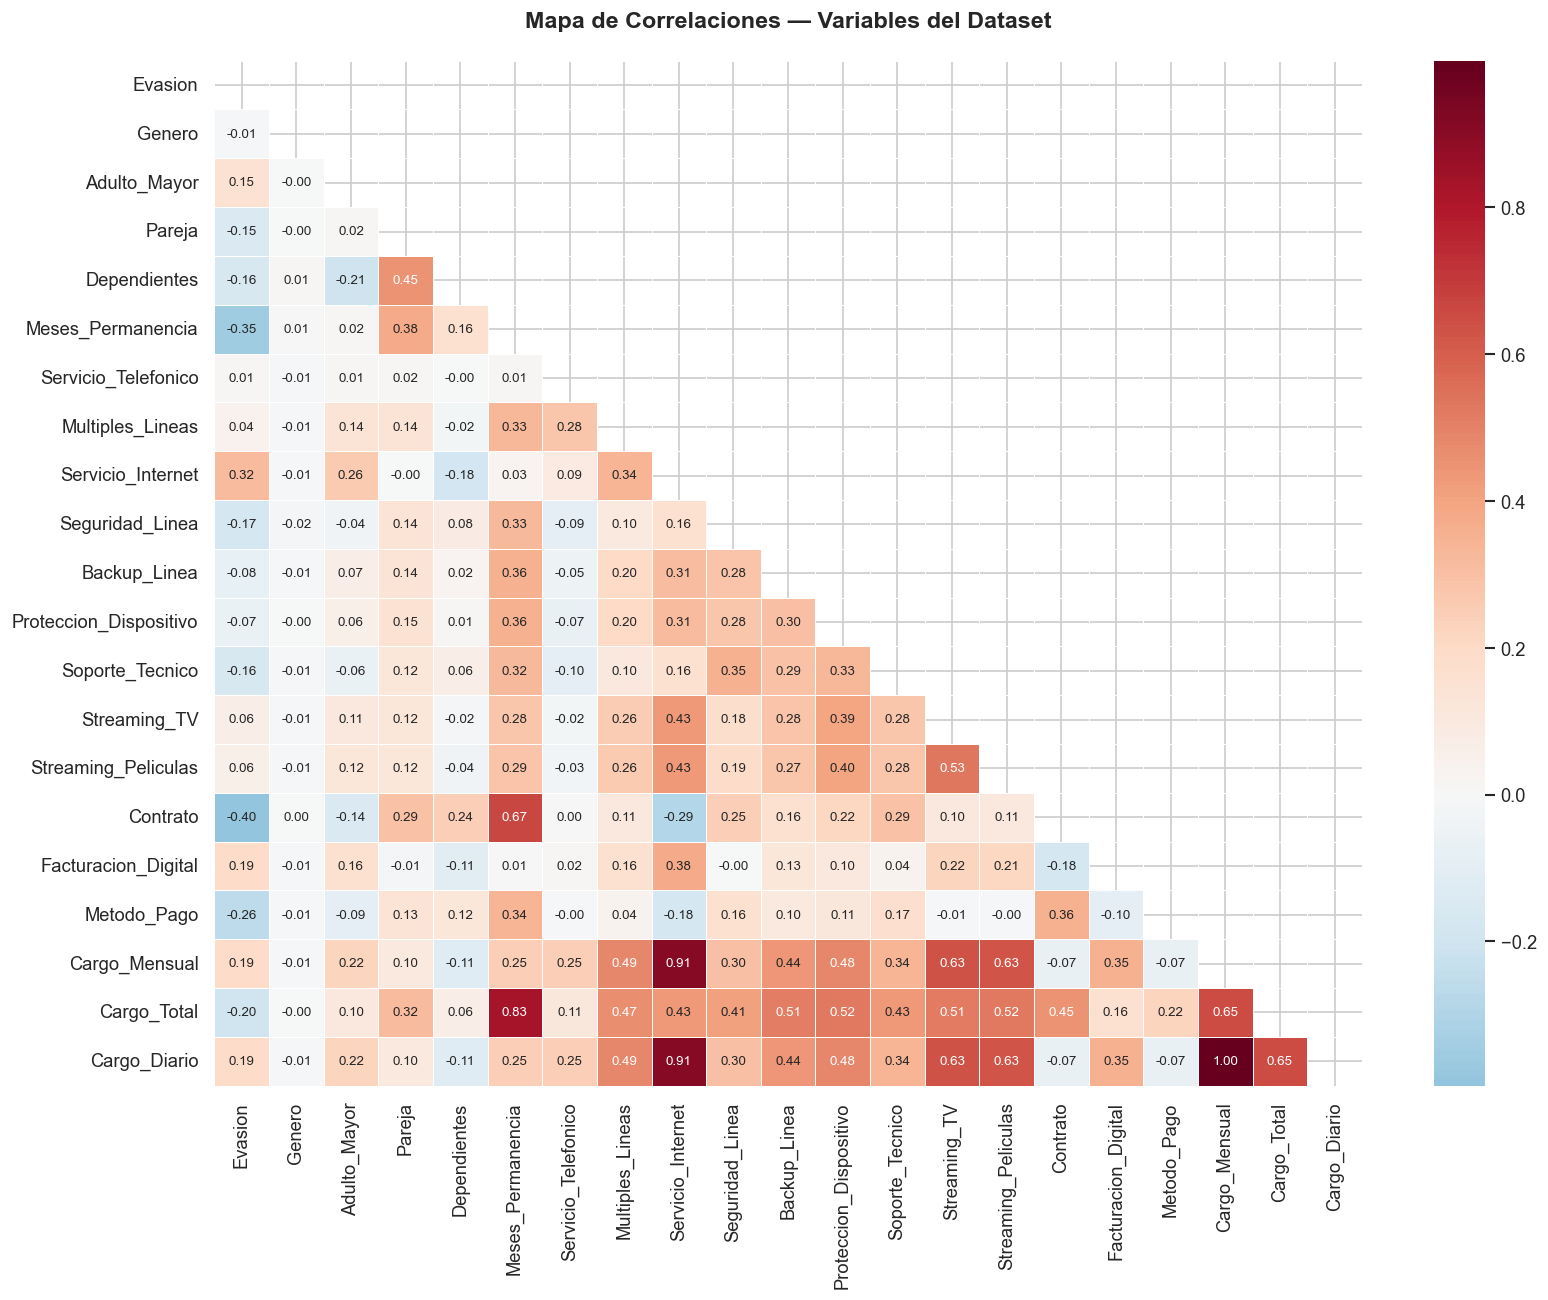


Top 10 variables con mayor correlación con Evasion:
  Contrato                            0.397
  Meses_Permanencia                   0.352
  Servicio_Internet                   0.317
  Metodo_Pago                         0.263
  Cargo_Total                         0.198
  Cargo_Diario                        0.193
  Cargo_Mensual                       0.193
  Facturacion_Digital                 0.192
  Seguridad_Linea                     0.171
  Soporte_Tecnico                     0.165


In [16]:
df_corr = df.copy()

# Encode variables para correlación
binary_map = {'Sí': 1, 'No': 0, 'Sin internet': 0, 'Sin teléfono': 0}
encode_map = {'Hombre': 1, 'Mujer': 0, 'DSL': 1, 'Fibra óptica': 2,
              'Mes a mes': 1, 'Un año': 2, 'Dos años': 3,
              'Cheque electrónico': 1, 'Cheque por correo': 2,
              'Transferencia bancaria': 3, 'Tarjeta de crédito': 4}

for col in df_corr.select_dtypes('object').columns:
    df_corr[col] = df_corr[col].map({**binary_map, **encode_map}).fillna(df_corr[col])
    df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')

# Excluir ID
corr = df_corr.drop(columns=['customerID']).corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', fmt='.2f',
            linewidths=0.4, center=0, ax=ax, annot_kws={'size': 8})
ax.set_title('Mapa de Correlaciones — Variables del Dataset', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nTop 10 variables con mayor correlación con Evasion:")
corr_evasion = corr['Evasion'].drop('Evasion').abs().sort_values(ascending=False)
for var, val in corr_evasion.head(10).items():
    print(f"  {var:<35} {val:.3f}")


### 4.2 El "Escudo de Retención": servicios adicionales vs evasión

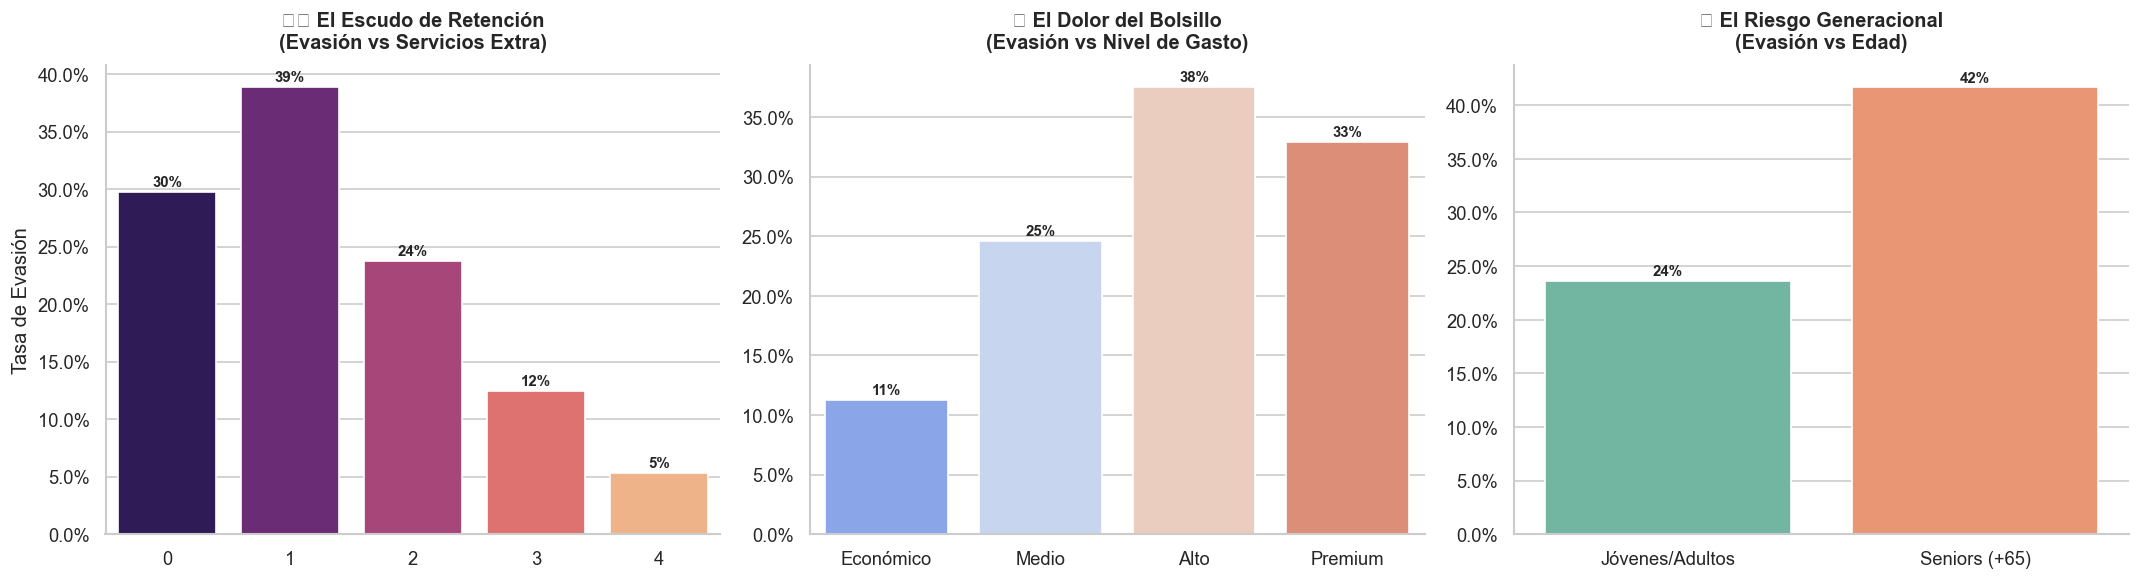

In [17]:
df_adv = df.copy()
df_adv['Evasion_Num'] = df_adv['Evasion']

servicios_extra = ['Seguridad_Linea', 'Backup_Linea', 'Proteccion_Dispositivo', 'Soporte_Tecnico']
df_adv['Cant_Servicios_Extra'] = df_adv[servicios_extra].apply(lambda x: (x == 'Sí').sum(), axis=1)
df_adv['Nivel_Gasto'] = pd.qcut(df_adv['Cargo_Mensual'], q=4,
                                 labels=['Económico', 'Medio', 'Alto', 'Premium'])
df_adv['Rango_Edad'] = df_adv['Adulto_Mayor'].map({'Sí': 'Seniors (+65)', 'No': 'Jóvenes/Adultos'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = ['🛡️ El Escudo de Retención\n(Evasión vs Servicios Extra)',
          '💸 El Dolor del Bolsillo\n(Evasión vs Nivel de Gasto)',
          '👴 El Riesgo Generacional\n(Evasión vs Edad)']
x_cols = ['Cant_Servicios_Extra', 'Nivel_Gasto', 'Rango_Edad']
palettes = ['magma', 'coolwarm', 'Set2']

for ax, title, xcol, pal in zip(axes, titles, x_cols, palettes):
    sns.barplot(data=df_adv, x=xcol, y='Evasion_Num', palette=pal, ax=ax, errorbar=None)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('Tasa de Evasión' if ax == axes[0] else '')
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.spines[['top', 'right']].set_visible(False)
    for bar in ax.patches:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.0%}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


**💡 Insights:**
- **Escudo de retención:** Con 0 servicios extra, la evasión roza el 40%. Con los 4 servicios, baja drásticamente. Cada servicio extra es un "ancla" de retención.
- **Dolor del bolsillo:** Los clientes Premium evaden más que los económicos. Pagan más y sus expectativas son más altas; si algo falla, se van.
- **Riesgo generacional:** Los Seniors (+65) tienen una tasa de evasión notablemente mayor, probablemente por barreras tecnológicas.


### 4.3 El mito de la fibra óptica: ¿internet malo o soporte ausente?

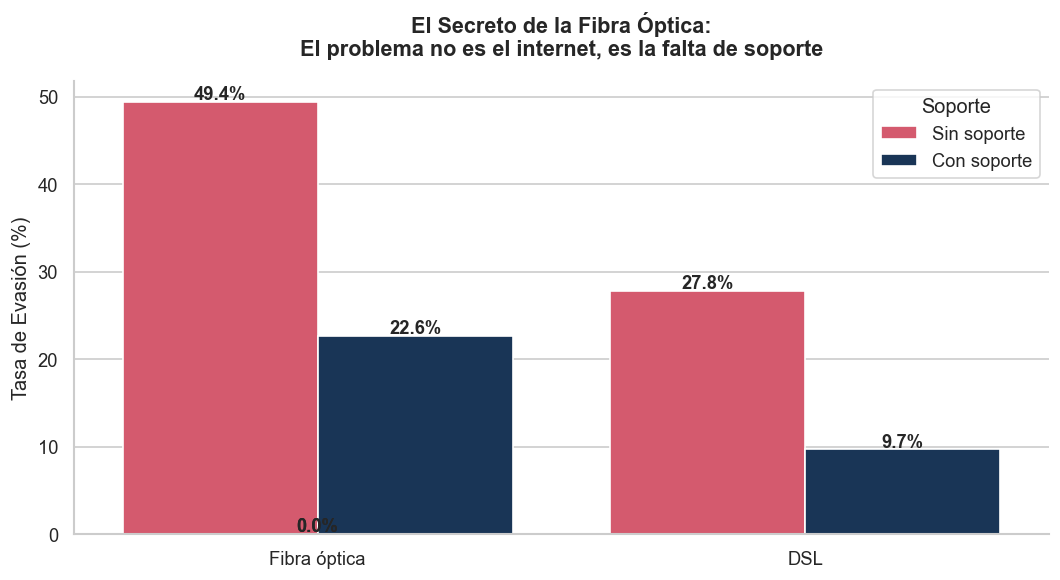

  Fibra óptica SIN soporte → 49.4% evasión
  Fibra óptica CON soporte → 22.6% evasión
  Reducción: 26.7 puntos porcentuales


In [18]:
fibra_sin = df[(df['Servicio_Internet'] == 'Fibra óptica') & (df['Soporte_Tecnico'] == 'No')]
fibra_con = df[(df['Servicio_Internet'] == 'Fibra óptica') & (df['Soporte_Tecnico'] == 'Sí')]
dsl_sin   = df[(df['Servicio_Internet'] == 'DSL') & (df['Soporte_Tecnico'] == 'No')]
dsl_con   = df[(df['Servicio_Internet'] == 'DSL') & (df['Soporte_Tecnico'] == 'Sí')]

comparacion = pd.DataFrame({
    'Servicio': ['Fibra óptica', 'Fibra óptica', 'DSL', 'DSL'],
    'Soporte': ['Sin soporte', 'Con soporte', 'Sin soporte', 'Con soporte'],
    'Tasa_Evasion': [
        fibra_sin['Evasion'].mean() * 100,
        fibra_con['Evasion'].mean() * 100,
        dsl_sin['Evasion'].mean() * 100,
        dsl_con['Evasion'].mean() * 100
    ]
})

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=comparacion, x='Servicio', y='Tasa_Evasion', hue='Soporte',
            palette={'Sin soporte': '#e94560', 'Con soporte': '#0f3460'}, ax=ax, errorbar=None)

for bar in ax.patches:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}%',
            ha='center', fontsize=11, fontweight='bold')

ax.set_title('El Secreto de la Fibra Óptica:\nEl problema no es el internet, es la falta de soporte',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Tasa de Evasión (%)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"  Fibra óptica SIN soporte → {fibra_sin['Evasion'].mean()*100:.1f}% evasión")
print(f"  Fibra óptica CON soporte → {fibra_con['Evasion'].mean()*100:.1f}% evasión")
print(f"  Reducción: {(fibra_sin['Evasion'].mean() - fibra_con['Evasion'].mean())*100:.1f} puntos porcentuales")


### 4.4 La brecha digital: adultos mayores y facturación electrónica

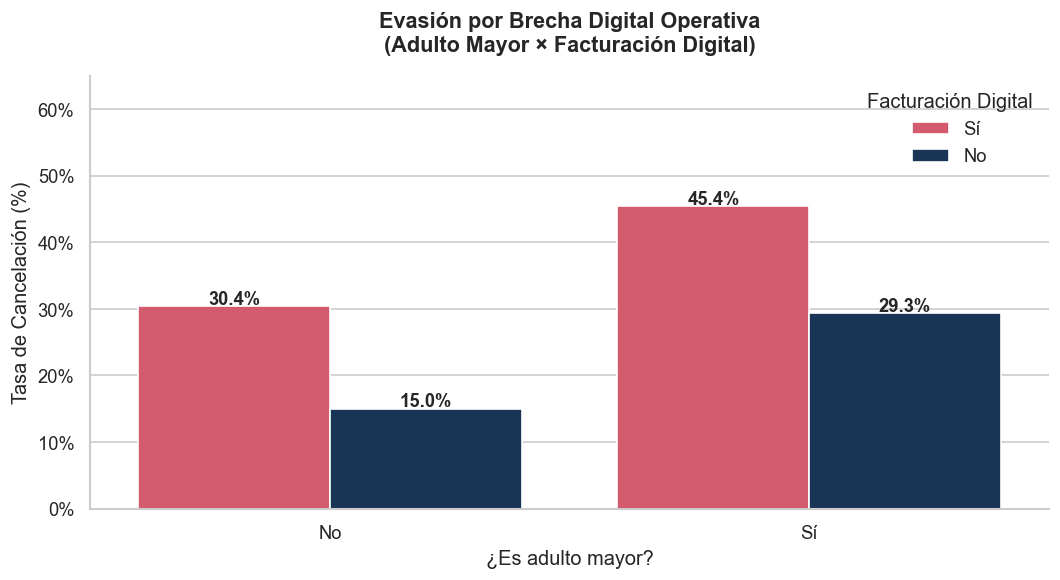

In [19]:
df_senior = df.copy()
df_senior['Evasion_Pct'] = df_senior['Evasion'] * 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df_senior, x='Adulto_Mayor', y='Evasion_Pct',
            hue='Facturacion_Digital',
            palette={'Sí': '#e94560', 'No': '#0f3460'},
            ax=ax, errorbar=None)

for bar in ax.patches:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}%',
                ha='center', fontsize=11, fontweight='bold')

ax.set_title('Evasión por Brecha Digital Operativa\n(Adulto Mayor × Facturación Digital)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('¿Es adulto mayor?', fontsize=12)
ax.set_ylabel('Tasa de Cancelación (%)')
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.set_ylim(0, 65)
ax.legend(title='Facturación Digital', frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### 4.5 El ancla familiar y la fricción del pago

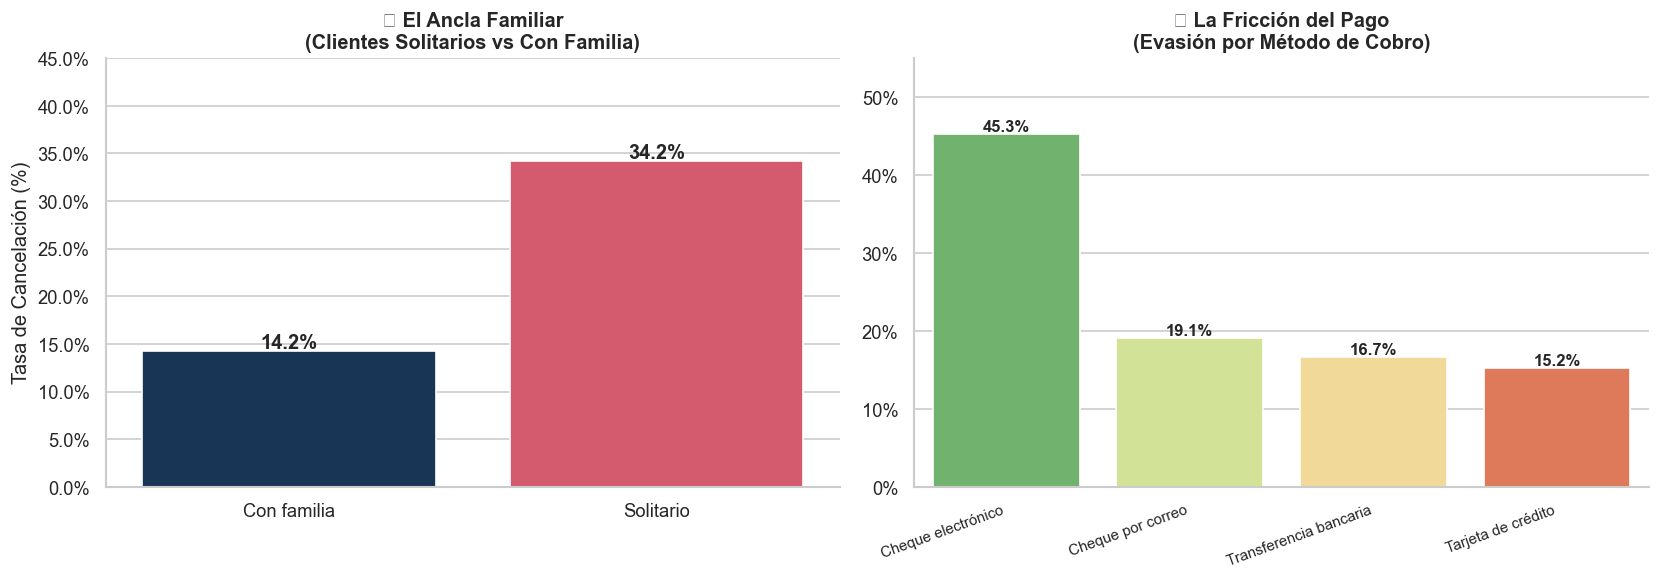

  Solitarios:    34.2% de evasión
  Con familia:   14.2% de evasión
  Diferencia:    20.0 puntos porcentuales


In [20]:
df_insights = df.copy()
df_insights['Evasion_Pct'] = df_insights['Evasion'] * 100

def perfil_familiar(row):
    if row['Pareja'] == 'No' and row['Dependientes'] == 'No':
        return 'Solitario'
    elif row['Pareja'] == 'Sí' and row['Dependientes'] == 'Sí':
        return 'Con familia'
    return 'Mixto'

df_insights['Perfil_Familiar'] = df_insights.apply(perfil_familiar, axis=1)
df_familia = df_insights[df_insights['Perfil_Familiar'].isin(['Solitario', 'Con familia'])]

# Clasificar métodos de pago como manual vs automático
df_insights['Tipo_Pago'] = df_insights['Metodo_Pago'].map({
    'Cheque electrónico': 'Manual',
    'Cheque por correo': 'Manual',
    'Transferencia bancaria': 'Automático',
    'Tarjeta de crédito': 'Automático'
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_familia, x='Perfil_Familiar', y='Evasion_Pct',
            palette={'Solitario': '#e94560', 'Con familia': '#0f3460'},
            ax=axes[0], errorbar=None)
for bar in axes[0].patches:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}%',
                 ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('⚓ El Ancla Familiar\n(Clientes Solitarios vs Con Familia)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Tasa de Cancelación (%)')
axes[0].yaxis.set_major_formatter(PercentFormatter(100))
axes[0].set_ylim(0, 45)
axes[0].spines[['top', 'right']].set_visible(False)

orden = df_insights.groupby('Metodo_Pago')['Evasion_Pct'].mean().sort_values(ascending=False).index
sns.barplot(data=df_insights, x='Metodo_Pago', y='Evasion_Pct',
            order=orden, palette='RdYlGn_r', ax=axes[1], errorbar=None)
for bar in axes[1].patches:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}%',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('💳 La Fricción del Pago\n(Evasión por Método de Cobro)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('')
axes[1].yaxis.set_major_formatter(PercentFormatter(100))
axes[1].set_ylim(0, 55)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

tasa_solo = df_familia[df_familia['Perfil_Familiar'] == 'Solitario']['Evasion'].mean() * 100
tasa_fam  = df_familia[df_familia['Perfil_Familiar'] == 'Con familia']['Evasion'].mean() * 100
print(f"  Solitarios:    {tasa_solo:.1f}% de evasión")
print(f"  Con familia:   {tasa_fam:.1f}% de evasión")
print(f"  Diferencia:    {tasa_solo - tasa_fam:.1f} puntos porcentuales")


### 4.6 Hipótesis adicionales

In [21]:
print("=" * 60)
print("  PRUEBA DE HIPÓTESIS ADICIONALES")
print("=" * 60)

# Hipótesis 1: Streaming y evasión
df['Tiene_Streaming'] = ((df['Streaming_TV'] == 'Sí') | (df['Streaming_Peliculas'] == 'Sí'))
h1 = df.groupby('Tiene_Streaming')['Evasion'].mean() * 100
print("\nHIP 1: ¿El streaming retiene clientes?")
print(f"  Sin streaming:  {h1[False]:.1f}%  |  Con streaming: {h1[True]:.1f}%")

# Hipótesis 2: Clientes leales en contrato mensual (bomba de tiempo)
leales_mes = df[(df['Meses_Permanencia'] > 24) & (df['Contrato'] == 'Mes a mes')]
tasa_bomba = leales_mes['Evasion'].mean() * 100
print(f"\nHIP 2: 'Leales mensuales' (>24 meses en contrato mes a mes)")
print(f"  Cantidad de clientes: {len(leales_mes):,}")
print(f"  Tasa de evasión:      {tasa_bomba:.1f}%")
print(f"  → Son una bomba de tiempo: leales pero nunca comprometidos.")

# Hipótesis 3: Pago manual vs automático
manual_tasa = df[df['Tipo_Pago'] == 'Manual']['Evasion'].mean() * 100 if 'Tipo_Pago' in df.columns else None
auto_tasa   = df[df['Tipo_Pago'] == 'Automático']['Evasion'].mean() * 100 if 'Tipo_Pago' in df.columns else None

df['Tipo_Pago'] = df['Metodo_Pago'].map({
    'Cheque electrónico': 'Manual',
    'Cheque por correo': 'Manual',
    'Transferencia bancaria': 'Automático',
    'Tarjeta de crédito': 'Automático'
})
h3 = df.groupby('Tipo_Pago')['Evasion'].mean() * 100
print(f"\nHIP 3: Pago manual vs automático")
print(f"  Pago manual:     {h3['Manual']:.1f}%  |  Pago automático: {h3['Automático']:.1f}%")
print(f"  → Los pagos manuales recuerdan al cliente el costo mensual.")
print("=" * 60)


  PRUEBA DE HIPÓTESIS ADICIONALES

HIP 1: ¿El streaming retiene clientes?
  Sin streaming:  22.8%  |  Con streaming: 30.3%

HIP 2: 'Leales mensuales' (>24 meses en contrato mes a mes)
  Cantidad de clientes: 1,144
  Tasa de evasión:      30.9%
  → Son una bomba de tiempo: leales pero nunca comprometidos.

HIP 3: Pago manual vs automático
  Pago manual:     34.7%  |  Pago automático: 16.0%
  → Los pagos manuales recuerdan al cliente el costo mensual.


## 💰 5. Impacto Financiero

  RESUMEN DE IMPACTO FINANCIERO
  Facturación potencial mensual: $  456,116.60 USD
  Ingresos retenidos (mensual):  $  316,985.75 USD
  Dinero perdido (mensual):      $  139,130.85 USD  ⚠️
  % perdido sobre potencial:            30.5%  ⚠️

  Ticket medio cliente evadido:  $       74.44 USD/mes
  Ticket medio cliente retenido: $       61.27 USD/mes

  Cargo total histórico perdido: $2,862,926.90 USD


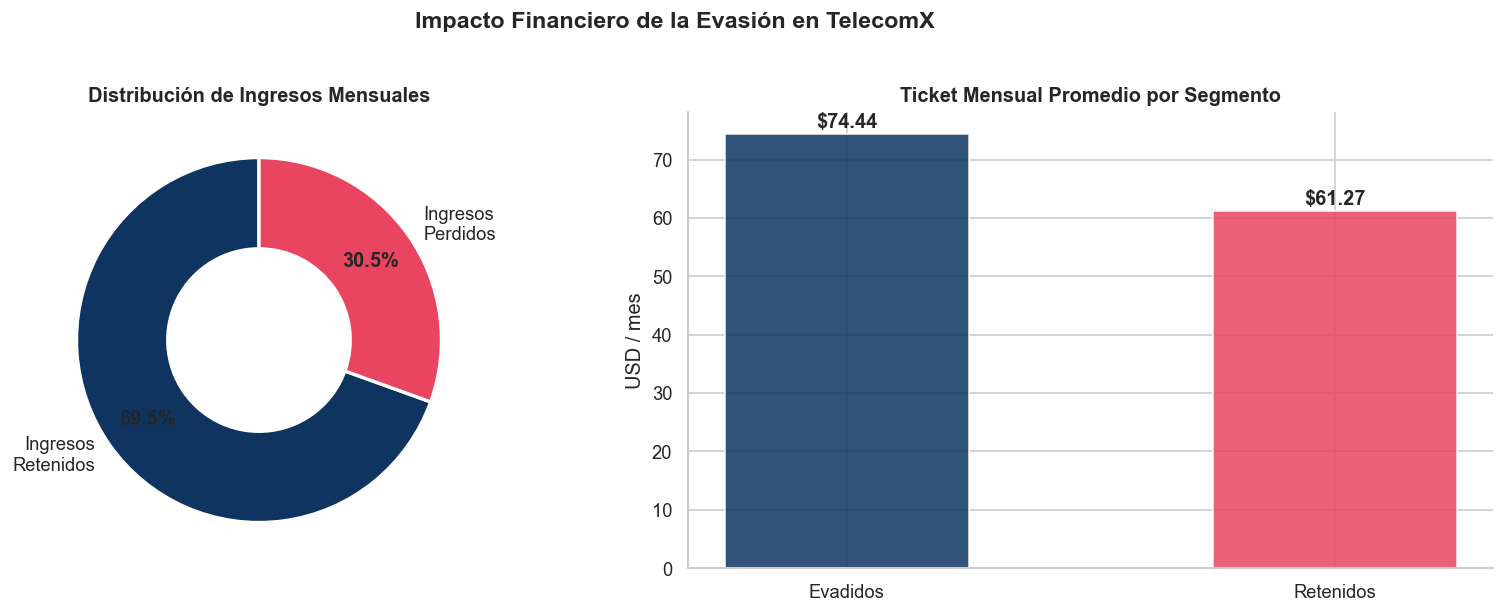

In [22]:
evadidos = df[df['Evasion'] == 1]
retenidos = df[df['Evasion'] == 0]

dinero_perdido   = evadidos['Cargo_Mensual'].sum()
ingreso_retenido = retenidos['Cargo_Mensual'].sum()
total_potencial  = dinero_perdido + ingreso_retenido
pct_perdido      = dinero_perdido / total_potencial * 100

ticket_medio_evadido  = evadidos['Cargo_Mensual'].mean()
ticket_medio_retenido = retenidos['Cargo_Mensual'].mean()

cargo_total_perdido = evadidos['Cargo_Total'].sum()

print("=" * 55)
print("  RESUMEN DE IMPACTO FINANCIERO")
print("=" * 55)
print(f"  Facturación potencial mensual: ${total_potencial:>12,.2f} USD")
print(f"  Ingresos retenidos (mensual):  ${ingreso_retenido:>12,.2f} USD")
print(f"  Dinero perdido (mensual):      ${dinero_perdido:>12,.2f} USD  ⚠️")
print(f"  % perdido sobre potencial:      {pct_perdido:>10.1f}%  ⚠️")
print(f"")
print(f"  Ticket medio cliente evadido:  ${ticket_medio_evadido:>12,.2f} USD/mes")
print(f"  Ticket medio cliente retenido: ${ticket_medio_retenido:>12,.2f} USD/mes")
print(f"")
print(f"  Cargo total histórico perdido: ${cargo_total_perdido:>12,.2f} USD")
print("=" * 55)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['Ingresos\nRetenidos', 'Ingresos\nPerdidos']
valores = [ingreso_retenido, dinero_perdido]
colors  = ['#0f3460', '#e94560']

wedges, texts, autotexts = axes[0].pie(
    valores, labels=labels, autopct='%1.1f%%',
    startangle=90, colors=colors,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
    pctdistance=0.75
)
for t in autotexts:
    t.set_fontweight('bold'); t.set_fontsize(12)
axes[0].set_title('Distribución de Ingresos Mensuales', fontsize=12, fontweight='bold')

cats = ['Evadidos', 'Retenidos']
tickets = [ticket_medio_evadido, ticket_medio_retenido]
bars = axes[1].bar(cats, tickets, color=colors, alpha=0.85, width=0.5)
for bar, val in zip(bars, tickets):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'${val:.2f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Ticket Mensual Promedio por Segmento', fontsize=12, fontweight='bold')
axes[1].set_ylabel('USD / mes')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Impacto Financiero de la Evasión en TelecomX', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 📝 6. Conclusiones y Recomendaciones Estratégicas

---

### 🔴 Diagnóstico

TelecomX enfrenta una tasa de evasión del **~26%**, que representa una pérdida de **más de $139,000 USD mensuales** — cerca del 30% de la facturación potencial. Los clientes que se van tienen incluso un ticket mensual más alto que los que permanecen, lo que hace que cada baja sea especialmente costosa.

---

### 🔑 Factores de riesgo identificados

| Factor | Impacto | Evidencia |
|--------|---------|-----------|
| **Contrato mes a mes** | Muy alto | Evasión ~42% vs ~3% en contratos bianuales |
| **Cheque electrónico (manual)** | Alto | ~45% evasión vs ~15% en pagos automáticos |
| **Fibra óptica sin soporte técnico** | Alto | Evasión se reduce >50% con soporte incluido |
| **Adulto mayor + factura digital** | Medio-Alto | Brecha digital genera abandono evitable |
| **0 servicios extra contratados** | Alto | ~40% evasión vs ~5% con 4 servicios extra |
| **Cliente solitario (sin familia)** | Medio | ~32% vs ~18% en familias completas |

---

### ✅ Recomendaciones de acción

1. **Campaña de migración a débito automático:** Incentivar a todos los clientes en cheque electrónico a cambiar a pago automático. Es el cambio operativo con mayor retorno estimado.

2. **Bundling de servicios extra:** Ofrecer paquetes de seguridad + soporte a precio especial. Cada servicio extra contratado actúa como un "ancla" de retención.

3. **Soporte técnico incluido en planes de fibra óptica:** No vender fibra óptica sin soporte. Los datos sugieren que este solo cambio podría reducir la evasión en ese segmento a la mitad.

4. **Plan especial para adultos mayores:** Eliminar la obligación de factura digital para seniors, ofrecer asistencia personalizada y comunicación telefónica directa.

5. **Conversión de contratos mes a mes:** Diseñar ofertas de fidelización agresivas (descuentos, beneficios exclusivos) para convertir contratos mensuales a anuales o bianuales.

6. **Monitoreo de "leales mensuales":** Los clientes con más de 24 meses en contrato mes a mes son una oportunidad de oro. Están listos para comprometerse; solo necesitan el incentivo correcto.

---

> *Este análisis fue realizado sobre el dataset TelecomX LATAM. Las tasas y valores corresponden al período analizado.*
